# NLP Practical Assignment 09
## WordNet — Semantic Relationship Extraction
### Synonymy · Antonymy · Hypernymy · Hyponymy · Meronymy · Holonymy · Similarity

---
### Pipeline Overview:
1. Install & Import Libraries
2. Introduction to WordNet & Synsets
3. Synonyms (words with same meaning)
4. Antonyms (words with opposite meaning)
5. Hypernyms (broader/parent concepts)
6. Hyponyms (narrower/child concepts)
7. Meronyms & Holonyms (part-of relationships)
8. Word Similarity using WordNet
9. Apply on Real-World Text Data
10. Visualize Semantic Tree
11. Save Outputs

## Step 1: Install & Import Libraries

In [1]:
!pip install nltk pandas matplotlib networkx

In [2]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from nltk.corpus import wordnet as wn
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from collections import defaultdict

# Download all required NLTK data
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

print("All libraries imported successfully!")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...


All libraries imported successfully!


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


## Step 2: Introduction to WordNet & Synsets

**WordNet** is a large English lexical database where words are grouped into **synsets** (sets of synonyms), each representing a distinct concept. Each synset has:
- A **definition**
- **Example sentences**
- **Lexical relations** (synonymy, antonymy, etc.)
- **Semantic relations** (hypernymy, hyponymy, etc.)

In [3]:
# Explore synsets for a word
word = 'dog'
synsets = wn.synsets(word)

print(f"Word: '{word}'")
print(f"Total Synsets found: {len(synsets)}")
print("=" * 60)

for syn in synsets:
    print(f"\nSynset  : {syn.name()}")
    print(f"POS     : {syn.pos()}  (n=noun, v=verb, a=adjective, r=adverb)")
    print(f"Definition: {syn.definition()}")
    if syn.examples():
        print(f"Examples: {syn.examples()}")
    print(f"Lemmas  : {[l.name() for l in syn.lemmas()]}")

Word: 'dog'
Total Synsets found: 8

Synset  : dog.n.01
POS     : n  (n=noun, v=verb, a=adjective, r=adverb)
Definition: a member of the genus Canis (probably descended from the common wolf) that has been domesticated by man since prehistoric times; occurs in many breeds
Examples: ['the dog barked all night']
Lemmas  : ['dog', 'domestic_dog', 'Canis_familiaris']

Synset  : frump.n.01
POS     : n  (n=noun, v=verb, a=adjective, r=adverb)
Definition: a dull unattractive unpleasant girl or woman
Examples: ['she got a reputation as a frump', "she's a real dog"]
Lemmas  : ['frump', 'dog']

Synset  : dog.n.03
POS     : n  (n=noun, v=verb, a=adjective, r=adverb)
Definition: informal term for a man
Examples: ['you lucky dog']
Lemmas  : ['dog']

Synset  : cad.n.01
POS     : n  (n=noun, v=verb, a=adjective, r=adverb)
Definition: someone who is morally reprehensible
Examples: ['you dirty dog']
Lemmas  : ['cad', 'bounder', 'blackguard', 'dog', 'hound', 'heel']

Synset  : frank.n.02
POS     : n  (n=n

## Step 3: Synonyms
**Synonyms** are words that share the same (or very similar) meaning. In WordNet, all lemmas within a synset are synonyms.

In [4]:
def get_synonyms(word):
    """Return all synonyms of a word using WordNet."""
    synonyms = set()
    for syn in wn.synsets(word):
        for lemma in syn.lemmas():
            name = lemma.name().replace('_', ' ')
            if name.lower() != word.lower():
                synonyms.add(name)
    return sorted(synonyms)

# Test on multiple words
test_words = ['happy', 'run', 'big', 'car', 'intelligent']

print("=" * 60)
print("SYNONYMS")
print("=" * 60)
synonym_records = []
for word in test_words:
    syns = get_synonyms(word)
    print(f"\n'{word}' --> {syns[:10]}")
    synonym_records.append({'Word': word, 'Synonyms': ', '.join(syns[:10])})

synonym_df = pd.DataFrame(synonym_records)
print("\n")
print(synonym_df.to_string(index=False))

SYNONYMS

'happy' --> ['felicitous', 'glad', 'well-chosen']

'run' --> ['be given', 'black market', 'bleed', 'break away', 'bunk', 'campaign', 'carry', 'consort', 'course', 'die hard']

'big' --> ['adult', 'bad', 'bighearted', 'boastful', 'boastfully', 'bounteous', 'bountiful', 'braggart', 'bragging', 'braggy']

'car' --> ['auto', 'automobile', 'cable car', 'elevator car', 'gondola', 'machine', 'motorcar', 'railcar', 'railroad car', 'railway car']

'intelligent' --> ['healthy', 'level-headed', 'levelheaded', 'reasoning', 'sound', 'thinking', 'well-informed']


       Word                                                                                                  Synonyms
      happy                                                                             felicitous, glad, well-chosen
        run               be given, black market, bleed, break away, bunk, campaign, carry, consort, course, die hard
        big            adult, bad, bighearted, boastful, boastfully, bounteous,

## Step 4: Antonyms
**Antonyms** are words with opposite meanings. In WordNet, antonymy is a lexical relation stored on lemmas.

In [5]:
def get_antonyms(word):
    """Return all antonyms of a word using WordNet."""
    antonyms = set()
    for syn in wn.synsets(word):
        for lemma in syn.lemmas():
            for ant in lemma.antonyms():
                antonyms.add(ant.name().replace('_', ' '))
    return sorted(antonyms)

# Test on multiple words
antonym_words = ['happy', 'good', 'hot', 'fast', 'love', 'strong', 'rich', 'light']

print("=" * 60)
print("ANTONYMS")
print("=" * 60)
antonym_records = []
for word in antonym_words:
    ants = get_antonyms(word)
    print(f"  '{word}' <--> {ants}")
    antonym_records.append({'Word': word, 'Antonyms': ', '.join(ants) if ants else 'None found'})

antonym_df = pd.DataFrame(antonym_records)
print("\n")
print(antonym_df.to_string(index=False))

ANTONYMS
  'happy' <--> ['unhappy']
  'good' <--> ['bad', 'badness', 'evil', 'evilness', 'ill']
  'hot' <--> ['cold']
  'fast' <--> ['slow']
  'love' <--> ['hate']
  'strong' <--> ['impotent', 'weak']
  'rich' <--> ['lean', 'poor', 'poor people']
  'light' <--> ['dark', 'extinguish', 'heavy']


  Word                          Antonyms
 happy                           unhappy
  good bad, badness, evil, evilness, ill
   hot                              cold
  fast                              slow
  love                              hate
strong                    impotent, weak
  rich           lean, poor, poor people
 light           dark, extinguish, heavy


## Step 5: Hypernyms
**Hypernyms** represent the *is-a* relationship going **upward** (broader/parent concept).
> Example: *Dog → Canine → Carnivore → Mammal → Animal*

In [6]:
def get_hypernyms(word, pos=wn.NOUN):
    """Return immediate hypernyms for the first synset of a word."""
    synsets = wn.synsets(word, pos=pos)
    if not synsets:
        return []
    return [h.lemma_names()[0].replace('_',' ') for h in synsets[0].hypernyms()]

def get_hypernym_chain(word, pos=wn.NOUN):
    """Return the full hypernym chain (path to root) for a word."""
    synsets = wn.synsets(word, pos=pos)
    if not synsets:
        return []
    chain = []
    current = synsets[0]
    while current.hypernyms():
        current = current.hypernyms()[0]
        chain.append(current.lemma_names()[0].replace('_', ' '))
    return chain

# Test words
hyper_words = ['dog', 'car', 'rose', 'apple', 'doctor', 'computer']

print("=" * 65)
print("HYPERNYMS (Is-A Hierarchy — going UP)")
print("=" * 65)
hypernym_records = []
for word in hyper_words:
    immediate = get_hypernyms(word)
    chain     = get_hypernym_chain(word)
    print(f"\n'{word}'")
    print(f"  Immediate Hypernyms : {immediate}")
    print(f"  Full Chain (to root): {word} → {' → '.join(chain)}")
    hypernym_records.append({
        'Word': word,
        'Immediate Hypernyms': ', '.join(immediate),
        'Hypernym Chain': ' → '.join([word] + chain)
    })

hypernym_df = pd.DataFrame(hypernym_records)
print("\n")
print(hypernym_df.to_string(index=False))

HYPERNYMS (Is-A Hierarchy — going UP)

'dog'
  Immediate Hypernyms : ['domestic animal', 'canine']
  Full Chain (to root): dog → domestic animal → animal → organism → living thing → whole → object → physical entity → entity

'car'
  Immediate Hypernyms : ['motor vehicle']
  Full Chain (to root): car → motor vehicle → self-propelled vehicle → wheeled vehicle → container → instrumentality → artifact → whole → object → physical entity → entity

'rose'
  Immediate Hypernyms : ['shrub']
  Full Chain (to root): rose → shrub → woody plant → vascular plant → plant → organism → living thing → whole → object → physical entity → entity

'apple'
  Immediate Hypernyms : ['edible fruit', 'pome']
  Full Chain (to root): apple → edible fruit → produce → food → solid → matter → physical entity → entity

'doctor'
  Immediate Hypernyms : ['medical practitioner']
  Full Chain (to root): doctor → medical practitioner → health professional → professional → adult → person → organism → living thing → whole → 

## Step 6: Hyponyms
**Hyponyms** are more specific/child concepts (*is-a* going **downward**).
> Example: *Animal → Dog, Cat, Horse, ...*

In [7]:
def get_hyponyms(word, pos=wn.NOUN):
    """Return immediate hyponyms for the first synset of a word."""
    synsets = wn.synsets(word, pos=pos)
    if not synsets:
        return []
    hypos = synsets[0].hyponyms()
    return [h.lemma_names()[0].replace('_', ' ') for h in hypos]

hypo_words = ['animal', 'vehicle', 'fruit', 'sport', 'furniture', 'music']

print("=" * 65)
print("HYPONYMS (Specific Sub-types — going DOWN)")
print("=" * 65)
hyponym_records = []
for word in hypo_words:
    hypos = get_hyponyms(word)
    print(f"\n'{word}' has {len(hypos)} hyponyms:")
    print(f"  {hypos[:12]}")
    hyponym_records.append({'Word': word, 'Hyponyms (sample)': ', '.join(hypos[:12])})

hyponym_df = pd.DataFrame(hyponym_records)
print("\n")
print(hyponym_df.to_string(index=False))

HYPONYMS (Specific Sub-types — going DOWN)

'animal' has 47 hyponyms:
  ['darter', 'poikilotherm', 'stayer', 'young', 'pleurodont', 'biped', 'pest', 'stunt', 'zooplankton', 'larva', 'pet', 'acrodont']

'vehicle' has 8 hyponyms:
  ['wheeled vehicle', 'rocket', 'bumper car', 'steamroller', 'craft', 'skibob', 'sled', 'military vehicle']

'fruit' has 29 hyponyms:
  ['rowanberry', 'pod', 'chokecherry', 'buffalo nut', 'pyxidium', 'olive', 'hip', 'hagberry', 'fruitlet', 'aggregate fruit', 'May apple', 'quandong']

'sport' has 20 hyponyms:
  ['track and field', 'skating', 'rowing', 'skiing', 'archery', 'water sport', 'cycling', 'spectator sport', 'racing', 'contact sport', 'riding', 'team sport']

'furniture' has 24 hyponyms:
  ['cabinet', 'Sheraton', 'hallstand', 'bedstead', 'bookcase', 'seat', 'lawn furniture', 'dining-room furniture', 'fitment', 'nest', 'wardrobe', 'wall unit']

'music' has 32 hyponyms:
  ['antiphony', 'pizzicato', 'Gilbert and Sullivan', 'serialism', 'Beethoven', 'syncopat

## Step 7: Meronyms & Holonyms
- **Meronyms** → *part-of* (what are the parts of X?): *Car → wheel, engine, door*
- **Holonyms** → *whole-of* (X is a part of what?): *Wheel → Car*

In [8]:
def get_meronyms(word, pos=wn.NOUN):
    """Return part meronyms and substance meronyms."""
    synsets = wn.synsets(word, pos=pos)
    if not synsets:
        return [], []
    syn = synsets[0]
    part_mero = [m.lemma_names()[0].replace('_',' ') for m in syn.part_meronyms()]
    subs_mero = [m.lemma_names()[0].replace('_',' ') for m in syn.substance_meronyms()]
    return part_mero, subs_mero

def get_holonyms(word, pos=wn.NOUN):
    """Return part holonyms and member holonyms."""
    synsets = wn.synsets(word, pos=pos)
    if not synsets:
        return [], []
    syn = synsets[0]
    part_holo   = [h.lemma_names()[0].replace('_',' ') for h in syn.part_holonyms()]
    member_holo = [h.lemma_names()[0].replace('_',' ') for h in syn.member_holonyms()]
    return part_holo, member_holo

mero_words = ['car', 'tree', 'computer', 'hand', 'book', 'flower']

print("=" * 65)
print("MERONYMS (Parts of X) & HOLONYMS (X is Part of)")
print("=" * 65)
mero_records = []
for word in mero_words:
    part_m, subs_m = get_meronyms(word)
    part_h, memb_h = get_holonyms(word)
    print(f"\n'{word}'")
    print(f"  Part Meronyms (parts of '{word}')    : {part_m}")
    print(f"  Substance Meronyms                  : {subs_m}")
    print(f"  Part Holonyms ('{word}' is part of) : {part_h}")
    print(f"  Member Holonyms                     : {memb_h}")
    mero_records.append({
        'Word': word,
        'Part Meronyms': ', '.join(part_m) or 'None',
        'Part Holonyms': ', '.join(part_h) or 'None',
        'Member Holonyms': ', '.join(memb_h) or 'None'
    })

mero_df = pd.DataFrame(mero_records)
print("\n")
print(mero_df.to_string(index=False))

MERONYMS (Parts of X) & HOLONYMS (X is Part of)

'car'
  Part Meronyms (parts of 'car')    : ['buffer', 'fender', 'floorboard', 'glove compartment', 'car window', 'accelerator', 'grille', 'first gear', 'car mirror', 'car door', 'reverse', 'stabilizer bar', 'bumper', 'car seat', 'high gear', 'window', 'tail fin', 'third gear', 'running board', 'air bag', 'hood', 'luggage compartment', 'automobile engine', 'roof', 'gasoline engine', 'auto accessory', 'sunroof', 'automobile horn', 'rear window']
  Substance Meronyms                  : []
  Part Holonyms ('car' is part of) : []
  Member Holonyms                     : []

'tree'
  Part Meronyms (parts of 'tree')    : ['stump', 'crown', 'burl', 'limb', 'trunk']
  Substance Meronyms                  : ['sapwood', 'heartwood']
  Part Holonyms ('tree' is part of) : []
  Member Holonyms                     : ['forest']

'computer'
  Part Meronyms (parts of 'computer')    : ['memory', 'computer accessory', 'hardware', 'diskette', 'disk cache', 'c

## Step 8: Word Similarity using WordNet
WordNet provides multiple similarity measures:
- **Path Similarity** — based on shortest path between synsets
- **Wu-Palmer Similarity** — based on depth in hierarchy
- **Leacock-Chodorow (LCH)** — path length + taxonomy depth

In [9]:
def word_similarity(word1, word2, pos=wn.NOUN):
    """Compute similarity between two words using multiple measures."""
    syns1 = wn.synsets(word1, pos=pos)
    syns2 = wn.synsets(word2, pos=pos)
    if not syns1 or not syns2:
        return None, None, None
    s1, s2 = syns1[0], syns2[0]
    path_sim = s1.path_similarity(s2)
    wup_sim  = s1.wup_similarity(s2)
    lch_sim  = s1.lch_similarity(s2) if s1.pos() == s2.pos() else None
    return round(path_sim,4) if path_sim else None, \
           round(wup_sim,4)  if wup_sim  else None, \
           round(lch_sim,4)  if lch_sim  else None

# Word pairs for similarity
word_pairs = [
    ('dog',   'cat'),
    ('dog',   'animal'),
    ('car',   'vehicle'),
    ('happy', 'joyful'),
    ('car',   'airplane'),
    ('book',  'novel'),
    ('doctor','nurse'),
    ('ocean', 'sea'),
    ('king',  'queen'),
    ('sun',   'moon'),
    ('dog',   'flower'),
    ('computer','laptop')
]

print("=" * 70)
print(f"{'Word 1':<12} {'Word 2':<12} {'Path Sim':>10} {'WuPalmer':>10} {'LCH':>8}")
print("=" * 70)
sim_records = []
for w1, w2 in word_pairs:
    ps, wup, lch = word_similarity(w1, w2)
    print(f"{w1:<12} {w2:<12} {str(ps):>10} {str(wup):>10} {str(lch):>8}")
    sim_records.append({'Word 1':w1,'Word 2':w2,'Path Similarity':ps,'Wu-Palmer':wup,'LCH':lch})

similarity_df = pd.DataFrame(sim_records)

Word 1       Word 2         Path Sim   WuPalmer      LCH
dog          cat                 0.2     0.8571   2.0281
dog          animal           0.3333      0.875    2.539
car          vehicle             0.2        0.8   2.0281
happy        joyful             None       None     None
car          airplane         0.1111     0.6667   1.4404
book         novel            0.0588     0.1111   0.8044
doctor       nurse              0.25     0.8696   2.2513
ocean        sea              0.3333        0.8    2.539
king         queen               0.1     0.5714    1.335
sun          moon                0.2       0.75   2.0281
dog          flower           0.1111        0.6   1.4404
computer     laptop              0.2     0.8182   2.0281


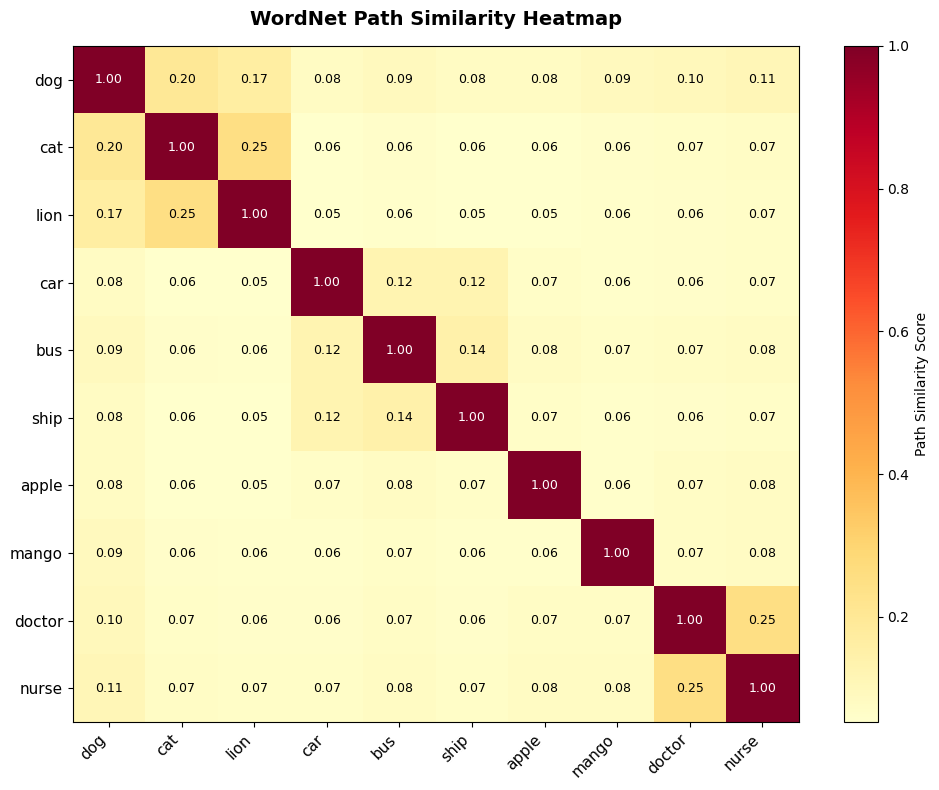

Saved: similarity_heatmap.png


In [10]:
import numpy as np

# Similarity heatmap for a set of words
heatmap_words = ['dog','cat','lion','car','bus','ship','apple','mango','doctor','nurse']
n = len(heatmap_words)
sim_matrix = np.zeros((n, n))

for i, w1 in enumerate(heatmap_words):
    for j, w2 in enumerate(heatmap_words):
        ps, _, _ = word_similarity(w1, w2)
        sim_matrix[i][j] = ps if ps else 0.0

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Path Similarity Score')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(heatmap_words, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(heatmap_words, fontsize=11)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='black' if sim_matrix[i,j] < 0.6 else 'white')
ax.set_title('WordNet Path Similarity Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: similarity_heatmap.png")

## Step 9: Apply on Real-World Text Data
Extract semantic relationships directly from real sentences.

In [11]:
# Real-world text samples
real_texts = [
    "The doctor examined the patient carefully in the hospital.",
    "Scientists discovered a new species of animal in the Amazon rainforest.",
    "The engineer designed a powerful computer system for the company.",
    "The student read a book about the history of ancient civilizations.",
    "The chef prepared a delicious meal with fresh vegetables and herbs.",
    "The athlete trained hard every day to win the championship."
]

# POS tag map to WordNet POS
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wn.ADJ
    elif treebank_tag.startswith('V'): return wn.VERB
    elif treebank_tag.startswith('N'): return wn.NOUN
    elif treebank_tag.startswith('R'): return wn.ADV
    return None

def analyze_text(text):
    """Analyze a sentence and extract semantic info for key nouns."""
    tokens = word_tokenize(text.lower())
    tagged = pos_tag(tokens)
    results = []
    seen = set()
    for token, tag in tagged:
        wn_pos = get_wordnet_pos(tag)
        if wn_pos != wn.NOUN or token in seen or len(token) <= 2:
            continue
        synsets = wn.synsets(token, pos=wn.NOUN)
        if not synsets:
            continue
        seen.add(token)
        syn = synsets[0]
        synonyms   = [l.name().replace('_',' ') for l in syn.lemmas() if l.name() != token][:4]
        antonyms   = [a.name().replace('_',' ') for l in syn.lemmas() for a in l.antonyms()][:3]
        hypernyms  = [h.lemma_names()[0].replace('_',' ') for h in syn.hypernyms()][:3]
        hyponyms   = [h.lemma_names()[0].replace('_',' ') for h in syn.hyponyms()][:3]
        results.append({
            'Word': token,
            'Definition': syn.definition()[:60] + '...' if len(syn.definition())>60 else syn.definition(),
            'Synonyms': synonyms,
            'Antonyms': antonyms if antonyms else ['—'],
            'Hypernyms': hypernyms,
            'Hyponyms': hyponyms
        })
    return results

print("=" * 70)
print("SEMANTIC ANALYSIS OF REAL-WORLD TEXT")
print("=" * 70)
all_text_records = []
for text in real_texts:
    print(f"\nText: \"{text}\"")
    print("-" * 65)
    results = analyze_text(text)
    for r in results:
        print(f"  Word      : {r['Word']}")
        print(f"  Definition: {r['Definition']}")
        print(f"  Synonyms  : {r['Synonyms']}")
        print(f"  Antonyms  : {r['Antonyms']}")
        print(f"  Hypernyms : {r['Hypernyms']}")
        print(f"  Hyponyms  : {r['Hyponyms']}")
        print()
        all_text_records.append({'Text': text[:50]+'...', **{k: str(v) for k,v in r.items()}})

text_analysis_df = pd.DataFrame(all_text_records)

SEMANTIC ANALYSIS OF REAL-WORLD TEXT

Text: "The doctor examined the patient carefully in the hospital."
-----------------------------------------------------------------
  Word      : doctor
  Definition: a licensed medical practitioner
  Synonyms  : ['doc', 'physician', 'MD', 'Dr.']
  Antonyms  : ['—']
  Hypernyms : ['medical practitioner']
  Hyponyms  : ['allergist', 'angiologist', 'primary care physician']

  Word      : patient
  Definition: a person who requires medical care
  Synonyms  : []
  Antonyms  : ['—']
  Hypernyms : ['case', 'sick person']
  Hyponyms  : ['hypertensive', 'analysand', 'hypotensive']

  Word      : hospital
  Definition: a health facility where patients receive treatment
  Synonyms  : ['infirmary']
  Antonyms  : ['—']
  Hypernyms : ['medical building']
  Hyponyms  : ['mental hospital', 'lazaretto', 'creche']


Text: "Scientists discovered a new species of animal in the Amazon rainforest."
-----------------------------------------------------------------
  W

## Step 10: Visualize Semantic Hierarchy Tree
Build a network graph showing the hypernym tree for selected words.

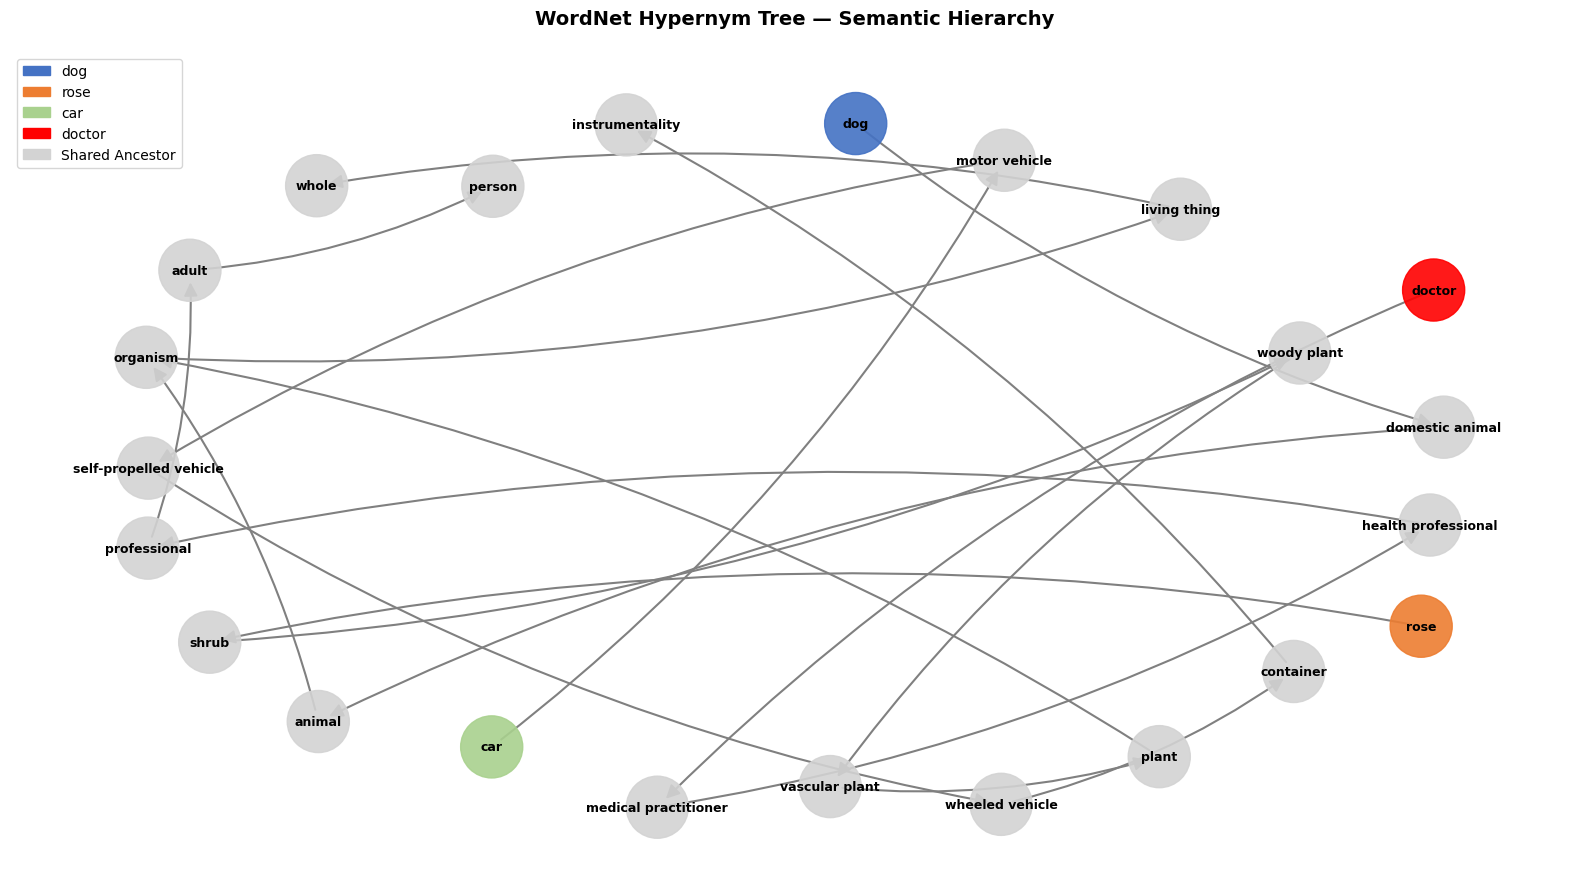

Saved: semantic_tree.png


In [12]:
def build_hypernym_graph(words, pos=wn.NOUN):
    """Build a directed graph of hypernym relationships."""
    G = nx.DiGraph()
    colors = {}
    color_palette = ['#4472C4','#ED7D31','#A9D18E','#FF0000','#7030A0','#00B0F0']

    for idx, word in enumerate(words):
        synsets = wn.synsets(word, pos=pos)
        if not synsets:
            continue
        current = synsets[0]
        prev_name = word
        G.add_node(prev_name)
        colors[prev_name] = color_palette[idx % len(color_palette)]
        depth = 0
        while current.hypernyms() and depth < 5:
            parent = current.hypernyms()[0]
            parent_name = parent.lemma_names()[0].replace('_', ' ')
            G.add_node(parent_name)
            G.add_edge(prev_name, parent_name)
            if parent_name not in colors:
                colors[parent_name] = '#D3D3D3'
            prev_name = parent_name
            current = parent
            depth += 1
    return G, colors

# Words to visualize
viz_words = ['dog', 'rose', 'car', 'doctor']
G, colors = build_hypernym_graph(viz_words)

fig, ax = plt.subplots(figsize=(16, 9))
pos_layout = nx.spring_layout(G, seed=42, k=2.5)
node_colors = [colors.get(n, '#D3D3D3') for n in G.nodes()]
nx.draw_networkx_nodes(G, pos_layout, node_color=node_colors, node_size=2000, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G, pos_layout, font_size=9, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos_layout, arrows=True, arrowsize=20,
                       edge_color='gray', width=1.5, ax=ax,
                       connectionstyle='arc3,rad=0.1')
ax.set_title('WordNet Hypernym Tree — Semantic Hierarchy', fontsize=14, fontweight='bold', pad=20)

# Legend for root words
color_palette = ['#4472C4','#ED7D31','#A9D18E','#FF0000']
legend_patches = [mpatches.Patch(color=color_palette[i], label=viz_words[i]) for i in range(len(viz_words))]
legend_patches.append(mpatches.Patch(color='#D3D3D3', label='Shared Ancestor'))
ax.legend(handles=legend_patches, loc='upper left', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.savefig('semantic_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: semantic_tree.png")

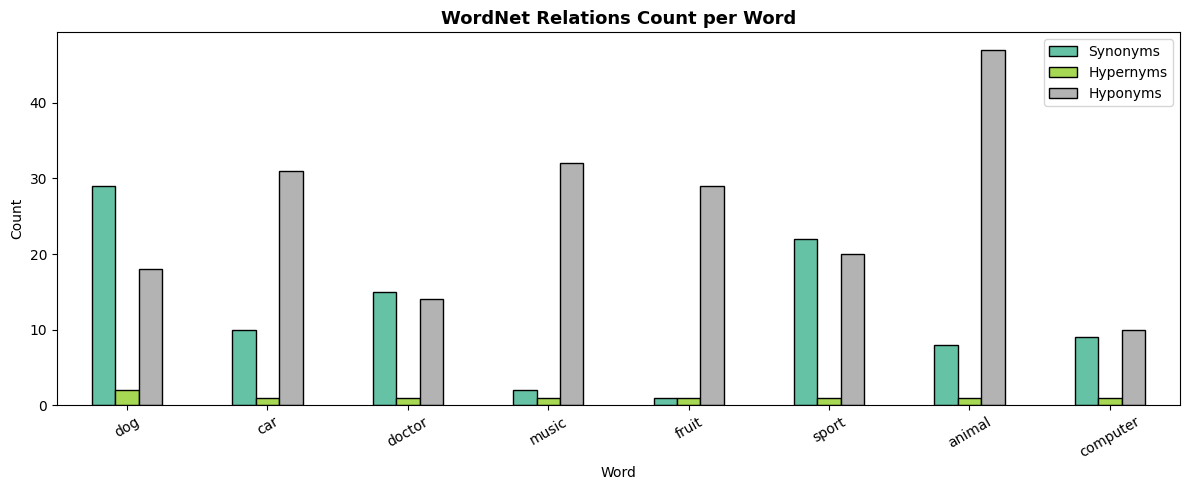

Saved: wordnet_relations_count.png


In [13]:
# Bar chart: Number of Synonyms, Hyponyms, Hypernyms per word
summary_words = ['dog','car','doctor','music','fruit','sport','animal','computer']
summary_rows = []
for word in summary_words:
    syns_c = len(get_synonyms(word))
    hyper_c = len(get_hypernyms(word))
    hypo_c  = len(get_hyponyms(word))
    summary_rows.append({'Word': word, 'Synonyms': syns_c,
                         'Hypernyms': hyper_c, 'Hyponyms': hypo_c})
bar_df = pd.DataFrame(summary_rows).set_index('Word')

bar_df.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black')
plt.title('WordNet Relations Count per Word', fontsize=13, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('wordnet_relations_count.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wordnet_relations_count.png")

## Step 11: Save All Outputs

In [14]:
# Save all DataFrames to CSV
synonym_df.to_csv('synonyms.csv', index=False)
print("Saved: synonyms.csv")

antonym_df.to_csv('antonyms.csv', index=False)
print("Saved: antonyms.csv")

hypernym_df.to_csv('hypernyms.csv', index=False)
print("Saved: hypernyms.csv")

hyponym_df.to_csv('hyponyms.csv', index=False)
print("Saved: hyponyms.csv")

mero_df.to_csv('meronyms_holonyms.csv', index=False)
print("Saved: meronyms_holonyms.csv")

similarity_df.to_csv('word_similarity.csv', index=False)
print("Saved: word_similarity.csv")

text_analysis_df.to_csv('text_semantic_analysis.csv', index=False)
print("Saved: text_semantic_analysis.csv")

print("\nAll outputs saved successfully!")

Saved: synonyms.csv
Saved: antonyms.csv
Saved: hypernyms.csv
Saved: hyponyms.csv
Saved: meronyms_holonyms.csv
Saved: word_similarity.csv
Saved: text_semantic_analysis.csv

All outputs saved successfully!


---
## Summary of Semantic Relationships Explored

| Relationship | Direction | Example |
|---|---|---|
| **Synonymy** | Same meaning | happy → joyful, glad, cheerful |
| **Antonymy** | Opposite meaning | happy ↔ sad |
| **Hypernymy** | Is-A (going UP) | dog → canine → mammal → animal |
| **Hyponymy** | Is-A (going DOWN) | animal → dog, cat, horse |
| **Meronymy** | Part-Of (parts of X) | car → wheel, engine, door |
| **Holonymy** | Whole-Of (X part of) | wheel → car |
| **Similarity** | Semantic closeness | dog–cat: 0.2, car–vehicle: 0.33 |

### Output Files:
| File | Contents |
|---|---|
| `synonyms.csv` | Synonym lists per word |
| `antonyms.csv` | Antonym lists per word |
| `hypernyms.csv` | Hypernym chains |
| `hyponyms.csv` | Hyponym lists |
| `meronyms_holonyms.csv` | Part-of relations |
| `word_similarity.csv` | Pairwise similarity scores |
| `text_semantic_analysis.csv` | Full analysis on real text |
| `similarity_heatmap.png` | Heatmap of word similarities |
| `semantic_tree.png` | Hypernym network graph |
| `wordnet_relations_count.png` | Bar chart of relation counts |